# Military Aircraft Classification 
CNN, ONNX checkpoints

## Dependencies and Preparation

Install dependencies

In [1]:
%pip -q install requests matplotlib numpy onnx onnxruntime pillow

Note: you may need to restart the kernel to use updated packages.


Download checkpoints and sample data

In [2]:
import io
import zipfile
from pathlib import Path

import requests

ZIPFILE_NAME = "ONNX_MilitaryAircraft"
DATA_DIR = Path("data")
DATA_PATH = DATA_DIR / ZIPFILE_NAME
ZIP_URL = f"https://github.com/Authentrics-ai/authentrics-analysis-example-models/raw/refs/heads/main/{ZIPFILE_NAME}.zip"

if DATA_PATH.exists():
    print(f"Data already exists in {DATA_PATH}")

else:
    print(f"Downloading data from {ZIP_URL}...")
    response = requests.get(ZIP_URL)
    if response.status_code != 200:
        raise Exception(f"Failed to download file: {response.text}")

    print("Extracting the zip file...")
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall(DATA_DIR)

    if not DATA_PATH.is_dir():
        raise Exception(f"Failed to extract data: {DATA_PATH}")

    print(f"Data extracted to {DATA_PATH}")


Data already exists in data/ONNX_MilitaryAircraft


## Implement `ModelInterface`

In [3]:
from pathlib import Path

import numpy as np
import onnx
import onnxruntime as ort
from PIL import Image

from authentrics import (
    InferenceResult,
    ModelInterface,
    TensorDict,
)


def preprocess_image(image_file: Path) -> np.ndarray:
    image = np.array(
        Image.open(image_file).convert("RGB").resize((224, 224)),
        dtype=np.float32,
    ).transpose(2, 0, 1)
    return image / 255.0


class SimpleModel(ModelInterface):
    def __init__(self) -> None:
        super().__init__()
        self.model = None

    def load(self, checkpoint_path: Path | str | bytes) -> None:
        self.model = onnx.load(checkpoint_path)

    def get_parameters(self, parameter_names: list[str] | None = None) -> TensorDict:
        # These contain (integer-valued) parameters that should not be optimized
        banned_ops = [
            "Reshape", "Transpose", "Cast", "Gather", "Slice", "Split",
            "Concat", "Pad", "Shape", "Squeeze", "Unsqueeze", "Flatten", "ReduceMean"
        ]
        banned_nodes = [node for node in self.model.graph.node if node.op_type in banned_ops]

        parameters = TensorDict()

        for initializer in self.model.graph.initializer:
            if parameter_names is not None and initializer.name not in parameter_names:
                continue

            should_skip = False
            for node in banned_nodes:
                if initializer.name in node.input:
                    should_skip = True
                    break

            if should_skip:
                continue

            parameters[initializer.name] = onnx.numpy_helper.to_array(initializer)

        return parameters

    def perform_inference(
        self,
        input_data: np.ndarray,
        return_intermediate_outputs: bool = False,
        layer_names: list[str] | None = None,
    ) -> InferenceResult:
        output_names: list[str] = [x.name for x in self.model.graph.output]
        input_name = self.model.graph.input[0].name

        intermediate_output_names: list[str] = []
        intermediate_layer_names: list[str] = []
        if return_intermediate_outputs:
            for node in self.model.graph.node:
                if layer_names is None or node.name in layer_names:
                    intermediate_output_names.append(node.output[0])
                    intermediate_layer_names.append(node.name)
                    self.model.graph.output.append(
                        onnx.ValueInfoProto(name=node.output[0])
                    )

        all_output_names = output_names + intermediate_output_names

        session = ort.InferenceSession(self.model.SerializeToString())
        ort_outputs = session.run(
            output_names=all_output_names,
            input_feed={input_name: input_data},
        )

        output = np.asarray(ort_outputs[0])
        intermediate_outputs = TensorDict(
            {
                layer_name: np.asarray(ort_outputs[i + 1])
                for i, layer_name in enumerate(intermediate_layer_names)
            }
        )

        return InferenceResult(output, intermediate_outputs)

    def set_parameters(self, parameters: TensorDict) -> None:
        for initializer in self.model.graph.initializer:
            if initializer.name in parameters:
                initializer.CopyFrom(
                    onnx.numpy_helper.from_array(
                        parameters[initializer.name], initializer.name
                    )
                )

    def save(self, checkpoint_path: Path | str | bytes) -> None:
        onnx.save(self.model, checkpoint_path)


In [4]:
from authentrics import AuthentricsSession

model = SimpleModel()
session = AuthentricsSession(model)

project = session.get_or_create_project(
    "MilAirClassificationExample-0630:ONNX",
    "Example project for ONNX-based CNN model",
)

checkpoint_paths = [DATA_PATH / f"checkpoint_{i}.onnx" for i in range(1, 8)]
assert all(path.is_file() for path in checkpoint_paths), "All checkpoint files must exist!"

checkpoint_paths

[PosixPath('data/ONNX_MilitaryAircraft/checkpoint_1.onnx'),
 PosixPath('data/ONNX_MilitaryAircraft/checkpoint_2.onnx'),
 PosixPath('data/ONNX_MilitaryAircraft/checkpoint_3.onnx'),
 PosixPath('data/ONNX_MilitaryAircraft/checkpoint_4.onnx'),
 PosixPath('data/ONNX_MilitaryAircraft/checkpoint_5.onnx'),
 PosixPath('data/ONNX_MilitaryAircraft/checkpoint_6.onnx'),
 PosixPath('data/ONNX_MilitaryAircraft/checkpoint_7.onnx')]

## Static Analysis

In [5]:
result = session.static_analysis(
    project.id,
    checkpoint_paths[0],
    checkpoint_paths[1],
    parameter_names=[
        "squeeze_edit_model.features.0.0.weight",
        "squeeze_edit_model.classifier.1.weight",
        "squeeze_edit_model.classifier.4.weight",
        "squeeze_edit_model.classifier.4.bias",
    ],
)

result

<StaticAnalysisResult object num_params=4, summary_score=0.004358666>

In [6]:
print(result.to_dataframe())

                                        parameter_changes
squeeze_edit_model.classifier.1.weight           0.004061
squeeze_edit_model.classifier.4.bias             0.005540
squeeze_edit_model.classifier.4.weight           0.004951
squeeze_edit_model.features.0.0.weight           0.109787


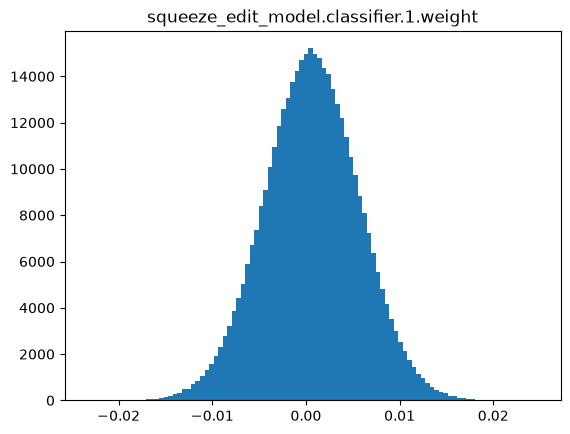

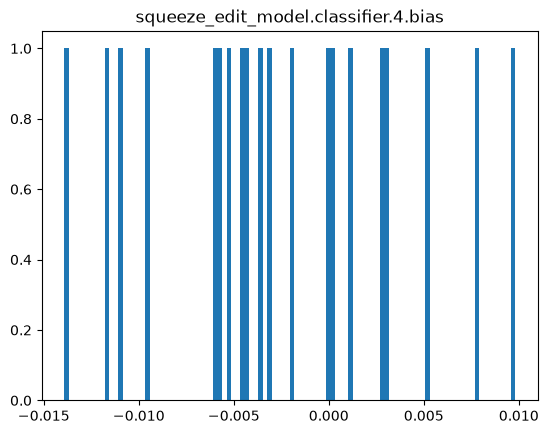

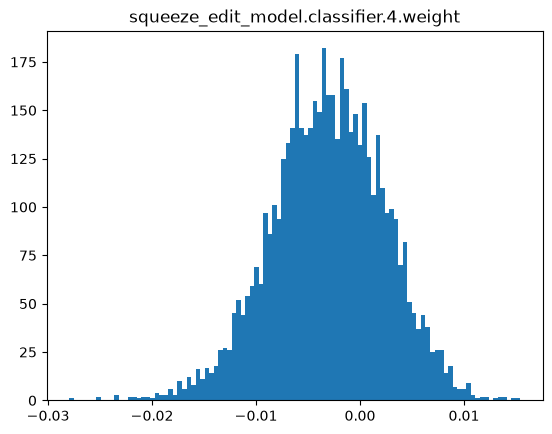

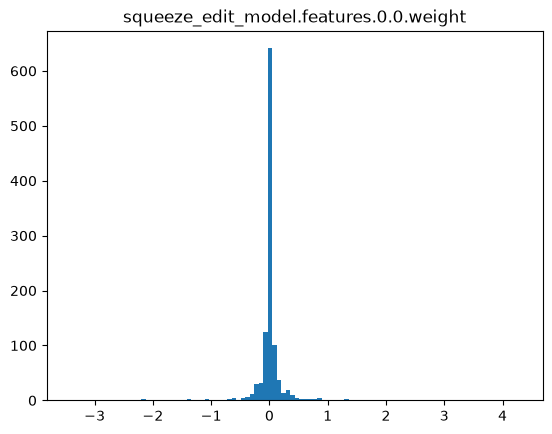

In [7]:
import matplotlib.pyplot as plt

for i, (param, hist) in enumerate(zip(result.parameter_names, result.parameter_histograms)):
    plt.figure(i)
    plt.hist((np.array(hist.bin_edges[1:]) + np.array(hist.bin_edges[:-1])) / 2, weights=hist.bin_counts, bins=hist.bin_edges)
    plt.title(param)

## Activation Analysis

In [8]:
image_paths = sorted((DATA_PATH / "stimuli").glob("*.jpg"))
print(image_paths)
input_data = np.stack([preprocess_image(image_path) for image_path in image_paths])
print(input_data.shape)

[PosixPath('data/ONNX_MilitaryAircraft/stimuli/F16-0.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F16-1.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F16-2.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F18.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F4-0.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F4-1.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F4-2.jpg')]
(7, 3, 224, 224)


In [9]:
result = session.activation_analysis(
    project.id,
    checkpoint_paths[0],
    checkpoint_paths[1],
    input_data,
    layer_names=[
        "node_Conv_1078",
        "node_Conv_1080",
        "node_Conv_1110",
        "node_Conv_1188",
        "node_Conv_1232",
        "node_linear_1",
    ],
)

In [10]:
print(result.to_dataframe())


                cosine_similarities  l2_distances
node_Conv_1078             0.994117    510.470490
node_Conv_1080             0.986739    518.678589
node_Conv_1110             0.934313    480.465698
node_Conv_1188             0.712248    339.227539
node_Conv_1232             0.702703    477.633026
node_linear_1              0.565965      8.456402


## Correlation Analysis

In [11]:
image_paths = sorted((DATA_PATH / "stimuli").glob("*.jpg"))
print(image_paths)
input_data = np.stack([preprocess_image(image_path) for image_path in image_paths])
print(input_data.shape)

[PosixPath('data/ONNX_MilitaryAircraft/stimuli/F16-0.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F16-1.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F16-2.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F18.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F4-0.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F4-1.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F4-2.jpg')]
(7, 3, 224, 224)


In [12]:
result = session.correlation_analysis(
    project.id,
    checkpoint_paths[1],
    input_data,
    layer_names=[
        "node_Conv_1078",
        "node_Conv_1080",
        "node_Conv_1110",
        "node_Conv_1188",
        "node_Conv_1232",
    ],
    reference_layer_name="node_linear_1",
)

In [13]:
print(result.to_dataframe())

                correlation_scores
node_Conv_1078            0.447806
node_Conv_1080            0.425004
node_Conv_1110            0.430122
node_Conv_1188            0.471633
node_Conv_1232            0.506754


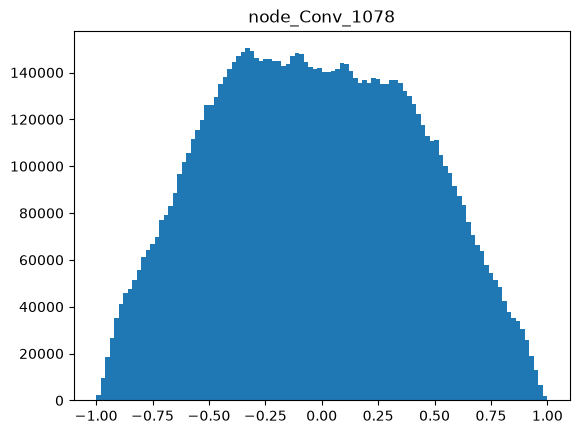

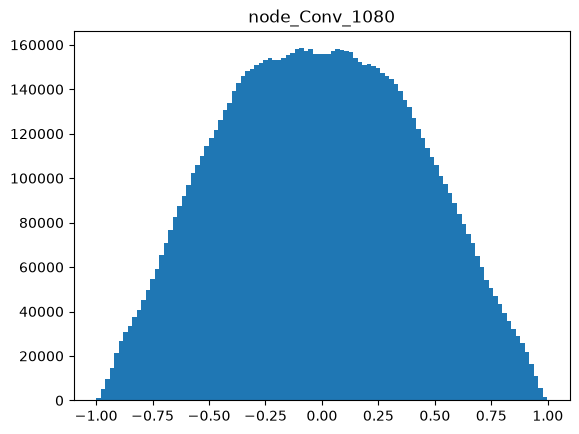

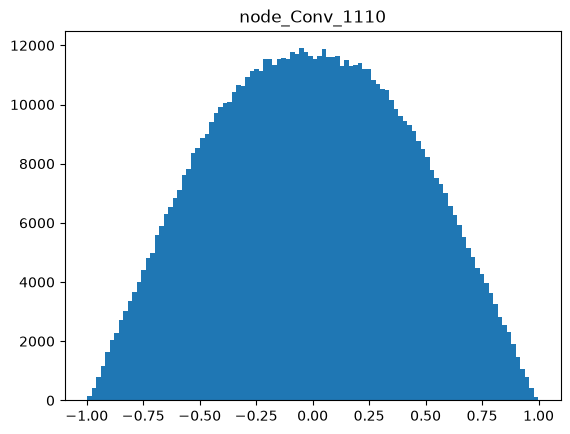

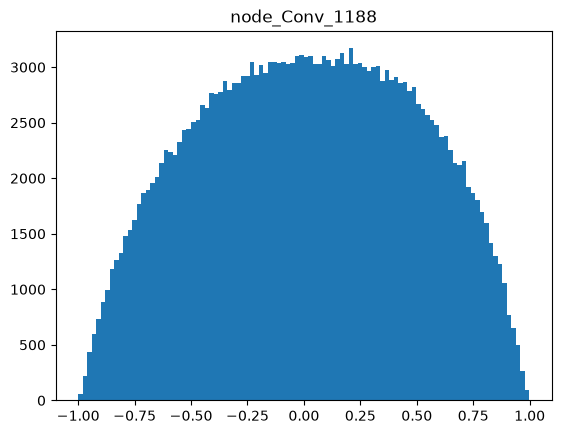

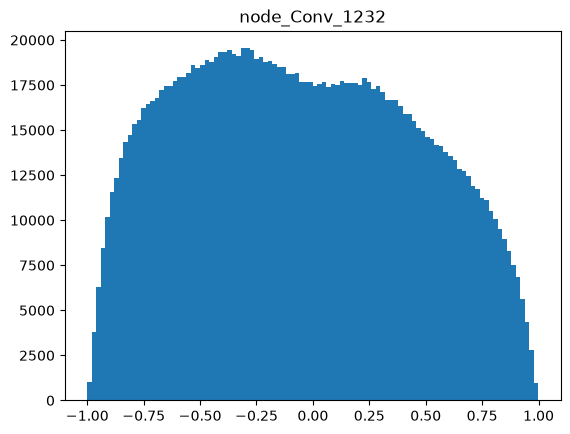

In [14]:
import matplotlib.pyplot as plt

for i, (param, hist) in enumerate(zip(result.layer_names, result.correlation_histograms)):
    plt.figure(i)
    plt.hist((np.array(hist.bin_edges[1:]) + np.array(hist.bin_edges[:-1])) / 2, weights=hist.bin_counts, bins=hist.bin_edges)
    plt.title(param)

## Exclude Training

In [15]:
session.exclude_training(
    project.id,
    checkpoint_paths,
    [2, 5],
    DATA_PATH / "excluded_3_and_6.onnx",
)

data/ONNX_MilitaryAircraft/excluded_3_and_6.onnx

In [16]:
(DATA_PATH / "excluded_3_and_6.onnx").is_file()

True

## Zero-Training Optimization & Maintenance (ZTOM)

In [17]:
import numpy as np

def milair_loss_function(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Computes the categorical cross-entropy loss between y_true and y_pred.

    y_true: numpy array of class indices (ground truth labels), shape (samples,).
    y_pred: numpy array of predicted logits, shape (samples, num_classes).

    Returns:
        scalar float loss (mean over samples).
    """
    logits = np.asarray(y_pred, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.intp).ravel()

    # Numerically stable log-softmax: log_softmax_i = logits_i - logsumexp(logits)
    logits_max = np.max(logits, axis=1, keepdims=True)
    log_sum_exp = (
        np.log(np.sum(np.exp(logits - logits_max), axis=1, keepdims=True)) + logits_max
    )
    log_softmax = logits - log_sum_exp

    # NLL: -log_softmax at the true class index
    n_samples = logits.shape[0]
    nll = -log_softmax[np.arange(n_samples), y_true]

    return float(np.mean(nll))

In [18]:
image_paths = sorted((DATA_PATH / "stimuli").glob("*.jpg"))
print(image_paths)
input_data = np.stack([preprocess_image(image_path) for image_path in image_paths])
print(input_data.shape)

[PosixPath('data/ONNX_MilitaryAircraft/stimuli/F16-0.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F16-1.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F16-2.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F18.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F4-0.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F4-1.jpg'), PosixPath('data/ONNX_MilitaryAircraft/stimuli/F4-2.jpg')]
(7, 3, 224, 224)


In [19]:
outputs = np.loadtxt(DATA_PATH / "expected_outputs.csv", delimiter=",")
expected_class_indices = outputs.argmax(axis=1)
expected_class_indices

array([ 9,  9,  9, 10, 13, 13, 13])

In [20]:
from authentrics import ZtomOptimizationOptions

# Optional: tune optimization parameters (defaults are often sufficient)
options = ZtomOptimizationOptions()

# loss_function: callable(model_output) -> float
# can be passed directly as a lambda or normal function
result = session.ztom_analysis(
    project.id,
    checkpoint_paths,
    input_data,
    loss_function=lambda y_pred: milair_loss_function(expected_class_indices, y_pred),
    new_checkpoint_path=DATA_PATH / "checkpoint_optimized.onnx",
    optimization_options=options,
)

In [21]:
print(result.scaling_factors)
print(result.number_of_inferences)

[-0.20743853152101194, 0.15750747036192958, -0.4565963242344468, 0.33082053610376416, -0.24720216172409443, -0.49731651756554135]
50
